In [1]:
import numpy as np
import matplotlib.pyplot as plt
import strawberryfields as sf
from strawberryfields.ops import Sgate, Dgate, BSgate, Vac
from numpy.polynomial.hermite import hermgauss
from scipy.special import eval_hermite, factorial

### Alice prepare complex displacement randomly with variance $V_a$

In [2]:
def alice_encode(raw_key_len, V_a):

    a_x = np.random.normal(loc=0, scale=np.sqrt(V_a), size=raw_key_len)
    a_p = np.random.normal(loc=0, scale=np.sqrt(V_a), size=raw_key_len)

    return a_x, a_p

### Bob measures randomly $\hat{p}$ or $\hat{x}$ quadrature with channel transmittance $\eta$

In [3]:
def bob_measure(a_x, a_p, raw_key_len, eta):

    choices = np.random.randint(0, 2, size=raw_key_len)
    measurements = np.zeros(raw_key_len)

    for i, choice in enumerate(choices):

        if choice==0:
            measurements[i] = np.random.normal(loc=np.sqrt(eta)*a_x[i], scale=1)

        elif choice==1:
            measurements[i] = np.random.normal(loc=np.sqrt(eta)*a_p[i], scale=1)

    return measurements, choices

### Alice communicates with Bob and discards misaligned displacement/measurements

In [4]:
def alice_align(bob_choices, a_x, a_p):

    measurements = np.zeros(bob_choices.size)
    for i, choice in enumerate(bob_choices):

        if choice==0:
            measurements[i] = a_x[i]
            
        elif choice==1:
            measurements[i] = a_p[i]

    return measurements

### Mutual Information $I(A:B)$ between Alice and Bob raw keys

In [5]:
def mutual_information(alice_measurements:np.array, bob_measurements:np.array):

    rho = np.corrcoef(alice_measurements, bob_measurements)[0, 1]

    return -0.5*np.log2(1 - rho**2)

### Holevo 

In [49]:
def G(x):
    if x==0:
        return 0
    return  (x + 1)*np.log2(x + 1) - x*np.log2(x)


def holevo_bound(lambda1, lambda2):
    return G((lambda1 - 1)/2) - G((lambda2 - 1)/2)

def lambda_RR(var_a, eta):
    lambda1 = 1+(1-eta)*var_a
    lambda2 = np.sqrt((1+(1-eta)*var_a)*(1+(1-eta)*var_a/(1+eta*var_a)))
    return lambda1, lambda2


def lambda_DR(var_a, eta):
    lambda1 = 1+(1-eta)*var_a
    lambda2 = 1
    return lambda1, lambda2


In [50]:
raw_key_len = 10000
eta = 0.1
displacement_grid = np.linspace(0, 100, 1001)
I = np.zeros(displacement_grid.size)
X = np.zeros(displacement_grid.size)

for i, alpha in enumerate(displacement_grid):

    a_x, a_p = alice_encode(raw_key_len=raw_key_len, V_a = alpha**2)
    bob_measurements, bob_choices = bob_measure(a_x, a_p, raw_key_len=raw_key_len, eta=eta)
    alice_measurements = alice_align(bob_choices, a_x, a_p)

    I[i] = mutual_information(alice_measurements, bob_measurements)
    X[i] = holevo_bound(*lambda_RR(alpha**2, eta))

In [ ]:
def I_theory(sigma_x, eta, V):

    I = 0.5*np.log2(1 + (sigma_x**2*eta)/(1 + eta*(V - 1)))
    return I

sigma_x = np.linspace(0, 100, 1001)

I_theory = np.array([I_theory(val, 0.3, 1) for val in sigma_x])



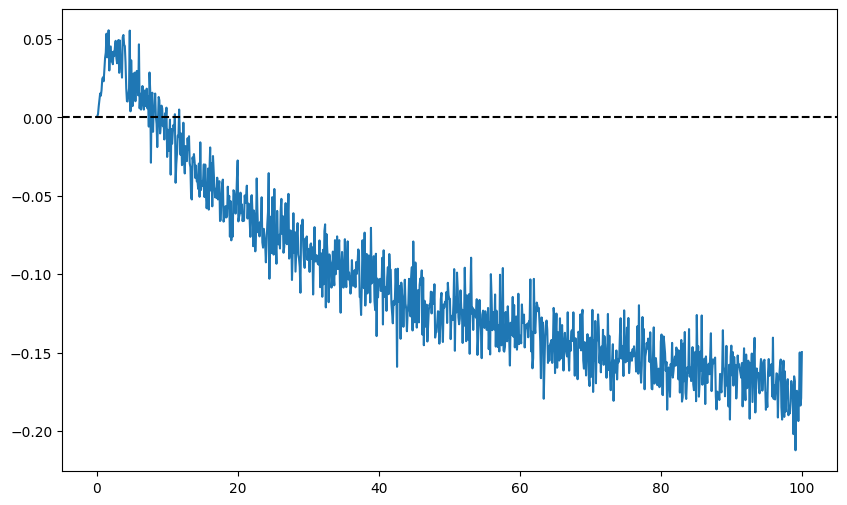

In [52]:
plt.figure(figsize=(10,6))
plt.plot(displacement_grid, 0.95*I - X)
plt.axhline(y=0, linestyle='--', color='k')
